Youtube Video Preformance Predictor

In [2]:
# import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [3]:
# prepare for the data
data = {
    'ctr': [3.2, 5.8, 2.1, 7.4, 4.5, 6.2, 1.8, 5.1, 3.9, 8.5,
            4.2, 2.8, 6.8, 3.5, 7.1, 2.4, 5.5, 4.8, 6.5, 3.1,
            7.8, 2.6, 5.3, 4.1, 6.9, 3.7, 8.1, 2.2, 5.9, 4.6],

    'total_views': [12000, 28000, 8500, 42000, 19000, 33000, 7000, 24000, 16000, 51000,
                    18000, 11000, 38000, 14500, 44000, 9500, 26000, 21000, 35000, 13000,
                    47000, 10000, 25000, 17500, 40000, 15000, 49000, 8000, 31000, 20000]
}

In [5]:
df = pd.DataFrame(data)
df.head()

,ctr,total_views
0,3.2,12000
1,5.8,28000
2,2.1,8500
3,7.4,42000
4,4.5,19000


In [23]:
df.describe()

,ctr,total_views
count,30.000000,30.000000
mean,4.880000,24433.333333
std,1.943406,13537.134962
min,1.800000,7000.000000
25%,3.275000,13375.000000
50%,4.700000,20500.000000
75%,6.425000,34500.000000
max,8.500000,51000.000000


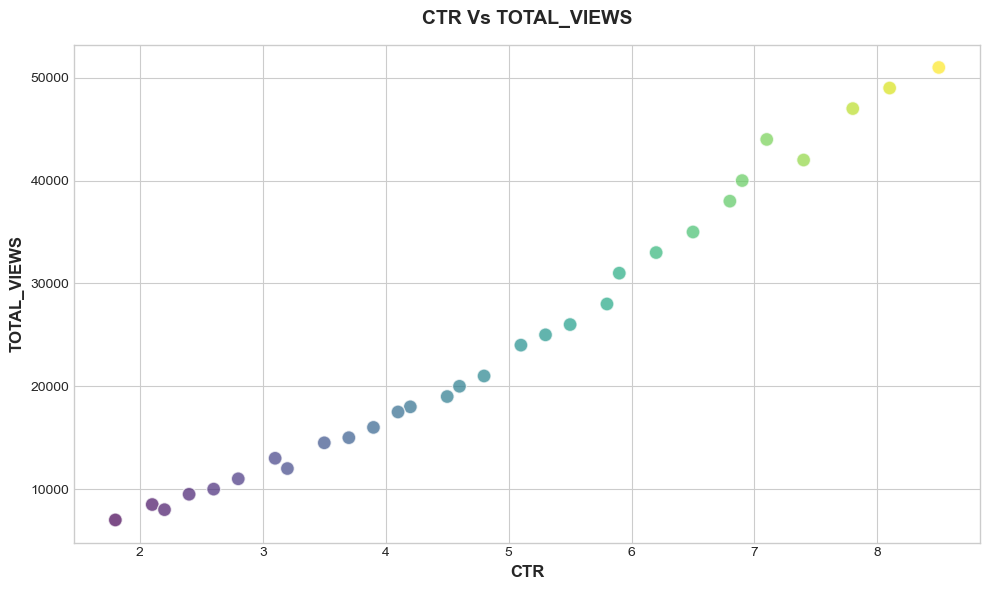

In [59]:
# Visualize the given data 
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10,6))
plt.scatter(df['ctr'],df['total_views'],c=df['ctr'], cmap='viridis', s=100, alpha=0.7, edgecolors='white')
plt.xlabel('CTR',fontsize=12, fontweight='bold')
plt.ylabel('TOTAL_VIEWS',fontsize=12, fontweight='bold')
plt.title("CTR Vs TOTAL_VIEWS",fontsize=14, fontweight='bold', pad = 15)
plt.tight_layout()
plt.show()

In [38]:
# prepare data for training
X = df[['ctr']] # sklearn expects 2-D array
y = df['total_views']

In [39]:
# splitting into training and testing data
random_state = 42
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2)


In [40]:
# create the model and train it
model = LinearRegression()
model.fit(X,y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
print("\nModel Parameters:")
print(f"Slope (Coefficient): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")


Model Parameters:
Slope (Coefficient): 6879.61
Intercept: -9139.17


In [42]:
y_test

0     12000
14    44000
5     33000
4     19000
26    49000
8     16000
Name: total_views, dtype: int64

In [45]:
# Make predictions on test data
y_pred = model.predict(X_test)
y_pred

array([12875.58736883, 39706.06907214, 33514.4194483 , 21819.08126993,
       46585.6797653 , 17691.31485404])

In [47]:
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round()})
results

,Actual,Predicted
0,12000,12876.0
1,44000,39706.0
2,33000,33514.0
3,19000,21819.0
4,49000,46586.0
5,16000,17691.0


C:\Users\G.Guna\desktop\ML\heart_disease_project\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


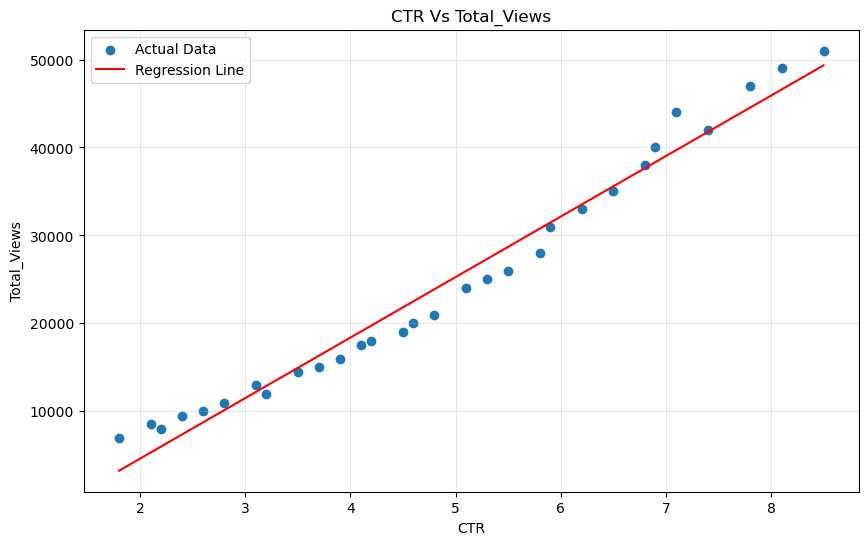

In [50]:
# Visualize the Regression Line
plt.figure(figsize = (10,6))
plt.scatter(df['ctr'],df['total_views'], label= 'Actual Data')
X_line = np.linspace(df['ctr'].min(), df['ctr'].max(),100).reshape(-1,1) 
'''we use linspace because the data what we had was not continuous which doesnot give the best regression line. so we need to take the 
min and max value form the given data and make more data which is 100 values so that we can expect the best regression line and reshape
to 2-D for the prediction of those values '''
plt.plot(X_line, model.predict(X_line), color = 'red', label= 'Regression Line')
plt.xlabel('CTR')
plt.ylabel('Total_Views')
plt.title('CTR Vs Total_Views')
plt.grid(True, alpha = 0.3)
plt.legend()
plt.show()

In [53]:
new_ctr = 8
new_pred_views = model.predict([[new_ctr]])
new_pred_views
print(f"\nArjun's Question: If I get {new_ctr}% CTR, how many views can i expect ?")
print(f"Predicted Total Views: {new_pred_views[0]:,.0f}")


Arjun's Question: If I get 8% CTR, how many views can i expect ?
Predicted Total Views: 45,898


C:\Users\G.Guna\desktop\ML\heart_disease_project\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
